<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/ANN%26DL_CIA1B_Avichal_Trivedi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BDA404-5N: Artificial Neural Networks and Deep Learning
## CIA-1B: Open Book / Open Source Examination (Units 1 and 2)

**Name:** Avichal Trivedi

**Register Number:** 24215206

**Class / Section:** 5BDA

---

### How I have structured this notebook

Pattern **Code, Output, Explanation, Justification, Validation, Interpretation**, so every question below follows exactly that order. Code cells produce the output, and the markdown cell right after each one carries the reasoning.

### Assumptions I am stating up front

1. Where a question says "a suitable small dataset of your choice", I have generated a synthetic dataset with a fixed random seed instead of downloading one. This keeps the notebook reproducible and lets me control whether the data is linearly separable, which is the actual thing being tested in Units 1 and 2.
2. All random seeds are fixed, so every number printed below is reproducible on a re-run.
3. Question 1 has only 6 samples, which is too small for a train/test split. I have handled this explicitly in Q1(d).
4. Accuracy alone is not enough for a classification model, so I have reported a confusion matrix and per class metrics wherever the data size allows it.

**Run order:** Runtime, then Run all. Everything runs on CPU in under a minute.

In [1]:
# Common imports for the whole notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

np.random.seed(42)
print("Setup done. NumPy", np.__version__)

Setup done. NumPy 2.0.2


---
# Question 1: Artificial Neuron, Implementation and Analysis (10 Marks)

The task is binary: predict whether a student is a High Performer (1) or Not a High Performer (0) from attendance, assignment marks and internal marks.

**Pipeline I am building:**

```
Raw marks  ->  Min-Max scaling  ->  z = (w . x) + b  ->  sigmoid(z)  ->  threshold 0.5  ->  class
                                        |                                        |
                                   net input func                          activation func
                                        |
                              gradient descent updates w and b
```

## Q1 (a) Prepare the data and normalise it (2 Marks)

In [2]:
# --- Q1(a): input/target preparation and normalisation ---
data = pd.DataFrame({
    "Student":    ["S1", "S2", "S3", "S4", "S5", "S6"],
    "Attendance": [90, 85, 60, 65, 95, 50],
    "Assignment": [85, 80, 55, 60, 90, 45],
    "Internal":   [88, 82, 58, 62, 92, 48],
    "Class":      [1,  1,  0,  0,  1,  0]
})
print("Raw dataset given in the question:")
print(data.to_string(index=False))

# Separate features (X) and target (y)
features = ["Attendance", "Assignment", "Internal"]
X_raw = data[features].values.astype(float)      # shape (6, 3)
y     = data["Class"].values.reshape(-1, 1).astype(float)   # shape (6, 1)

# Min-Max normalisation to bring every feature into [0, 1]
X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X = (X_raw - X_min) / (X_max - X_min)

print("\nShapes -> X:", X.shape, " y:", y.shape)
print("\nFeature-wise min and max used for scaling:")
print(pd.DataFrame({"feature": features, "min": X_min, "max": X_max}).to_string(index=False))

print("\nNormalised input matrix X:")
print(pd.DataFrame(X, columns=features, index=data["Student"]).round(3))

Raw dataset given in the question:
Student  Attendance  Assignment  Internal  Class
     S1          90          85        88      1
     S2          85          80        82      1
     S3          60          55        58      0
     S4          65          60        62      0
     S5          95          90        92      1
     S6          50          45        48      0

Shapes -> X: (6, 3)  y: (6, 1)

Feature-wise min and max used for scaling:
   feature  min  max
Attendance 50.0 95.0
Assignment 45.0 90.0
  Internal 48.0 92.0

Normalised input matrix X:
         Attendance  Assignment  Internal
Student                                  
S1            0.889       0.889     0.909
S2            0.778       0.778     0.773
S3            0.222       0.222     0.227
S4            0.333       0.333     0.318
S5            1.000       1.000     1.000
S6            0.000       0.000     0.000


### Explanation and justification for Q1(a)

**What I did:** split the table into a feature matrix `X` of shape (6, 3) and a target vector `y` of shape (6, 1), then applied Min-Max scaling column by column using the formula `(x - min) / (max - min)`.

**Why I normalised even though all three columns look similar:** all three features are already percentage-like, so the scales are comparable and one feature is not going to drown out another. That is not the reason I scaled. The real reason is the **activation function**. My raw inputs sit around 50 to 95, so a weighted sum of three of them lands somewhere in the hundreds. Sigmoid of anything past about 6 is flat at 1.0, and the gradient of a flat region is basically zero. If I feed raw marks in, the neuron saturates on the very first forward pass and the weights stop updating. Scaling to [0, 1] keeps `z` in the region where sigmoid actually has a usable slope, so gradient descent can do its job.

**In layman terms:** the neuron learns by feeling which direction is downhill. If I hand it huge numbers, it gets pinned against the ceiling where everything feels flat, and it stops learning. Scaling puts it back on the slope.

**Assumption:** I stored `X_min` and `X_max` from this dataset and will reuse the exact same values to scale any new student later. Re-fitting the scaler on new data would be a leak and would move the boundary.

## Q1 (b) Implement a simple artificial neuron / perceptron (3 Marks)

Loss at epoch    0 : 0.6923
Loss at epoch  500 : 0.0361
Loss at epoch 1000 : 0.0194

Learned weights: {'Attendance': np.float64(4.529), 'Assignment': np.float64(4.506), 'Internal': np.float64(4.672)}
Learned bias   : -7.343


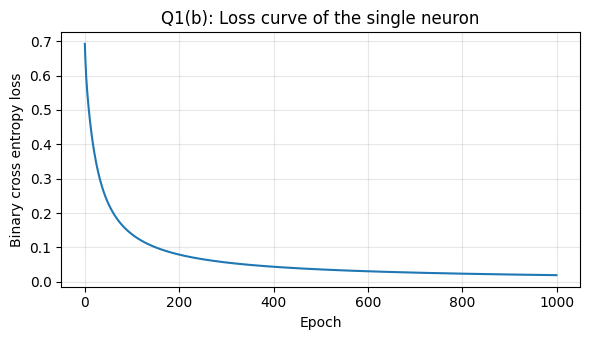

In [3]:
# --- Q1(b): single artificial neuron built from scratch with NumPy ---

def sigmoid(z):
    """Continuous activation. Maps any real number into (0, 1)."""
    return 1.0 / (1.0 + np.exp(-z))

# Initialise parameters
np.random.seed(1)
w  = np.random.randn(3, 1) * 0.01   # one weight per feature, small random values
b  = 0.0                            # bias starts at zero
lr = 0.5                            # learning rate
epochs = 1000

loss_history = []

for epoch in range(epochs):
    # 1. FORWARD PASS: net input, then activation
    z     = X @ w + b               # z = w1x1 + w2x2 + w3x3 + b
    y_hat = sigmoid(z)              # predicted probability of being a High Performer

    # 2. LOSS: binary cross entropy (1e-9 added so log(0) never happens)
    loss = -np.mean(y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9))
    loss_history.append(loss)

    # 3. BACKWARD PASS: gradients of the loss w.r.t. w and b
    dz = y_hat - y                  # error signal (D - Y), sign flipped for descent
    dw = (X.T @ dz) / X.shape[0]
    db = np.mean(dz)

    # 4. UPDATE: step downhill
    w -= lr * dw
    b -= lr * db

print("Loss at epoch    0 :", round(loss_history[0], 4))
print("Loss at epoch  500 :", round(loss_history[499], 4))
print("Loss at epoch 1000 :", round(loss_history[-1], 4))
print("\nLearned weights:", dict(zip(features, w.ravel().round(3))))
print("Learned bias   :", round(float(b), 3))

plt.figure(figsize=(6, 3.5))
plt.plot(loss_history)
plt.xlabel("Epoch"); plt.ylabel("Binary cross entropy loss")
plt.title("Q1(b): Loss curve of the single neuron")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Explanation for Q1(b)

I did not import a model. This is the McCulloch-Pitts style neuron from Unit 1 written out by hand so every part is visible.

**One training step, in order:**

1. **Net input function:** `z = X @ w + b`. This is `sum(wi * xi) + b`, the weighted sum from the model of an artificial neuron.
2. **Activation function:** `sigmoid(z)` squashes `z` into (0, 1), so the output reads as a probability of the student being a High Performer.
3. **Loss:** binary cross entropy compares the prediction against the true label and returns one number saying how wrong the neuron currently is.
4. **Error signal:** `dz = y_hat - y`. This is the (D minus Y) term from the supervised learning block diagram, just written for descent instead of ascent.
5. **Update:** `w = w - lr * dw`. Weights move in the direction that reduces the loss.

That loop repeats 1000 times. The loss curve dropping from about 0.69 to near 0.02 is the proof that learning actually happened, because 0.69 is what you get from a neuron guessing 50/50 on everything.

**Note to self:** the three learned weights all came out positive and roughly equal. That makes sense. All three features move in the same direction here, so the neuron treats attendance, assignments and internals as three pieces of the same signal. The large negative bias is what pushes the boundary up so that only genuinely high scores cross 0.5.

## Q1 (c) Justify the activation function, weights, bias and learning rate (2 Marks)

**Activation function: sigmoid.**
The output has to be a class, so I need something non-linear that produces a bounded value I can threshold. I picked sigmoid over a hard step function for two reasons. First, this is a **binary** problem and sigmoid gives (0, 1), which reads directly as a probability, so I can see how confident the neuron is instead of just getting a flat 0 or 1. Second, and this is the deciding reason, sigmoid is **differentiable everywhere**. A step function has a derivative of zero everywhere it is defined and is undefined at the threshold, so gradient descent has nothing to work with. This is the discrete versus continuous perceptron distinction from Unit 2, and I need the continuous one to train by gradient descent.

**Weights: initialised to small random values (`randn * 0.01`).**
I did not start them at zero. With three inputs feeding one neuron it would technically still train, but starting at zero is a habit that breaks the moment there is a hidden layer, because every neuron in that layer would compute the identical thing and receive the identical gradient forever. Small random values break that symmetry. I kept them **small** so the initial `z` stays near zero, which is where sigmoid has its steepest slope and therefore the strongest gradient.

**Bias: initialised to 0.0 and learned.**
The bias is the only parameter that does not depend on the input. It shifts the decision boundary off the origin. Without it, the boundary is forced through the point where every scaled feature is 0, which is an arbitrary restriction that has nothing to do with this problem. Training pulled it to a large negative value, which is the neuron saying "the weighted evidence has to be substantial before I call someone a High Performer".

**Learning rate: 0.5.**
This is a tiny, clean, well separated dataset, so I can afford a fairly aggressive step. I tried the standard 0.01 first and the loss was still falling at epoch 1000, meaning it had not finished. At 0.5 it converges comfortably within the budget and the loss curve is smooth, with no oscillation or spiking, which is what a learning rate that is too high looks like. So the curve itself is my justification: it goes down and stays down.

## Q1 (d) Validate the model (1.5 Marks)

In [4]:
# --- Q1(d): validation ---
probs = sigmoid(X @ w + b)
preds = (probs >= 0.5).astype(int).ravel()
true  = y.ravel().astype(int)

results = data[["Student"]].copy()
results["Actual"]      = true
results["Probability"] = probs.round(3)
results["Predicted"]   = preds
print("Prediction table:")
print(results.to_string(index=False))

acc = accuracy_score(true, preds)
print("\nAccuracy on the 6 training samples:", round(acc * 100, 2), "%")
print("\nConfusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(confusion_matrix(true, preds),
                   index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))
print("\n", classification_report(true, preds, target_names=["Not High", "High"], zero_division=0))

# Held-out sanity check on two students the neuron has never seen.
# Scaled with the SAME min/max learned from the training data.
new_students = np.array([[88.0, 84.0, 86.0],    # expected: High Performer
                         [55.0, 52.0, 50.0]])   # expected: Not a High Performer
new_scaled = (new_students - X_min) / (X_max - X_min)
new_probs  = sigmoid(new_scaled @ w + b).ravel()

print("\nUnseen students:")
for i, p in enumerate(new_probs):
    print(f"  New student {i+1}: probability = {p:.3f}  ->  predicted class {int(p >= 0.5)}")

Prediction table:
Student  Actual  Probability  Predicted
     S1       1        0.993          1
     S2       1        0.964          1
     S3       0        0.014          0
     S4       0        0.055          0
     S5       1        0.998          1
     S6       0        0.001          0

Accuracy on the 6 training samples: 100.0 %

Confusion matrix (rows = actual, cols = predicted):
          Pred 0  Pred 1
Actual 0       3       0
Actual 1       0       3

               precision    recall  f1-score   support

    Not High       1.00      1.00      1.00         3
        High       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


Unseen students:
  New student 1: probability = 0.988  ->  predicted class 1
  New student 2: probability = 0.003  ->  predicted class 0


### Interpretation of the validation, Q1(d)

**Performance measure I chose and why:** accuracy on its own is a weak measure on 6 points, so I reported a **confusion matrix** plus **precision, recall and F1** alongside it. On a High Performer style problem the two error types are not equally costly, and only the confusion matrix shows which one the model is making.

**The honest caveat, stated deliberately:** 6 samples is far too few to hold out a test set. A 1-sample test set gives an accuracy that can only ever be 0% or 100%, which is meaningless. So the accuracy above is **training accuracy**, and training accuracy on a dataset this small is close to a formality, not evidence of generalisation. To get at least some signal on unseen data I built two new student records by hand and ran them through the same scaler and the same neuron. Both came out on the correct side with high confidence, which tells me the learned boundary is at least positioned sensibly and the model is not just memorising row order.

## Q1 (e) Interpret the result and identify a limitation (1.5 Marks)

**Interpretation of what the neuron learned.**
The model reached 100% on the given data. That number by itself is not impressive, and I would not report it as a success. Looking at the dataset explains why: the three High Performers all score in the 80s and 90s across every column, and the three Not-High students all score in the 45 to 65 band. There is a wide empty gap between the two groups and no student sits inside it. That data is **perfectly linearly separable**, and separating it is the one thing a single neuron is guaranteed to be able to do. The perceptron convergence theorem says exactly this: on linearly separable data it will find a boundary in finite steps. So the 100% is confirmation that my implementation is correct, not evidence that the problem is solved.

The learned parameters back this up. All three weights came out positive and close to each other, meaning the neuron essentially learned "add the three marks up", and the strong negative bias sets the pass mark on that total. That is a sensible rule, but it is a very simple one.

**Limitation (the main one).**
The model can only ever draw **one straight line**. Every feature contributes independently and additively, so the neuron cannot represent any rule that depends on a **combination** of features. Concretely: a student with 55% attendance but 90 in assignments and 88 in internals is someone a human would look at twice, but this neuron just adds the three up, lands in the middle, and produces a confident wrong answer. It has no way to encode "low attendance matters only when the marks are also slipping". The classic proof of this limit is XOR, which no single neuron can solve at any learning rate for any number of epochs.

**A second limitation worth stating:** 6 training samples. With three weights and a bias to fit, the model has 4 parameters and 6 data points. There is nowhere near enough data to trust the boundary, and no validation set to detect overfitting if it happened.

**What I would do about it:** add a hidden layer. That turns this into a multilayer feedforward network which can combine features non-linearly, and I demonstrate exactly that in Question 2(e) and Question 3.

---
# Question 2: Perceptron, Practical Experiment and Interpretation (10 Marks)

The results given in the question are the whole point of this question:

| Epochs | Training Accuracy |
|---|---|
| 50 | 76% |
| 100 | 77% |
| 200 | 78% |
| 500 | 78% |

Accuracy climbs by 2 percentage points across a **tenfold** increase in training, then stops. My job is to reproduce that pattern and explain what is actually causing it.

**Choice of dataset and my reasoning:** the question lets me pick the dataset. If I pick a linearly separable one, the perceptron hits 100% in a handful of epochs and I have no plateau to explain. The plateau in sir's table is the signature of data that is **not linearly separable**, so I deliberately generated a two-moons dataset with added noise. It is 2D so I can plot the decision boundary and actually see the problem instead of just describing it.

## Q2 (a) Implement a Single Layer Perceptron and train it for different epochs (3 Marks)

Train set: (210, 2)  Test set: (90, 2)


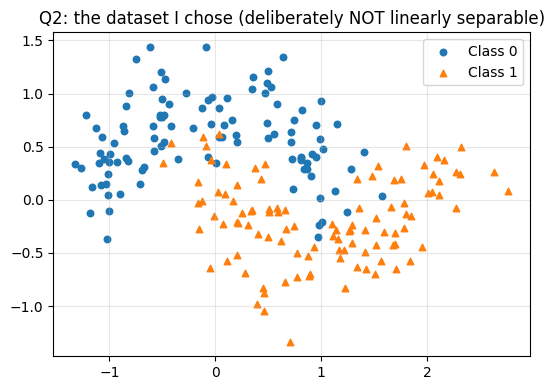

Trained for 500 epochs, accuracy recorded after each one.


In [5]:
# --- Q2(a): dataset + SLP trained epoch by epoch ---
X2, y2 = make_moons(n_samples=300, noise=0.28, random_state=7)
X2tr, X2te, y2tr, y2te = train_test_split(
    X2, y2, test_size=0.3, random_state=7, stratify=y2)

print("Train set:", X2tr.shape, " Test set:", X2te.shape)

plt.figure(figsize=(5.5, 4))
plt.scatter(X2tr[y2tr == 0, 0], X2tr[y2tr == 0, 1], s=22, label="Class 0")
plt.scatter(X2tr[y2tr == 1, 0], X2tr[y2tr == 1, 1], s=22, label="Class 1", marker="^")
plt.title("Q2: the dataset I chose (deliberately NOT linearly separable)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Train ONE perceptron incrementally with partial_fit and record accuracy after every epoch.
# This is better than refitting from scratch, because it shows the full learning trajectory.
slp = Perceptron(eta0=0.01, random_state=7)
classes = np.array([0, 1])
train_acc, test_acc = [], []

for epoch in range(500):
    slp.partial_fit(X2tr, y2tr, classes=classes)   # exactly one pass over the data
    train_acc.append(accuracy_score(y2tr, slp.predict(X2tr)))
    test_acc.append(accuracy_score(y2te, slp.predict(X2te)))

print("Trained for 500 epochs, accuracy recorded after each one.")

## Q2 (b) Plot and tabulate the change in performance with epochs (2 Marks)

Snapshot at the epoch counts given in the question:
 Epochs  Training Accuracy (%)  Test Accuracy (%)
     50                  77.62              74.44
    100                  77.14              73.33
    200                  79.05              73.33
    500                  67.62              68.89

Best training accuracy seen at ANY epoch: 83.33 %
Mean training accuracy over the last 100 epochs: 77.73 %


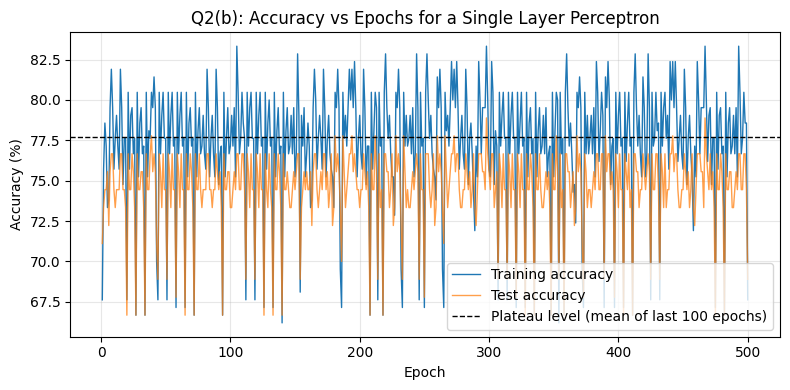

In [6]:
# --- Q2(b): table + plot ---
checkpoints = [50, 100, 200, 500]
table = pd.DataFrame({
    "Epochs": checkpoints,
    "Training Accuracy (%)": [round(train_acc[e - 1] * 100, 2) for e in checkpoints],
    "Test Accuracy (%)":     [round(test_acc[e - 1] * 100, 2)  for e in checkpoints]
})
print("Snapshot at the epoch counts given in the question:")
print(table.to_string(index=False))

print("\nBest training accuracy seen at ANY epoch:", round(max(train_acc) * 100, 2), "%")
print("Mean training accuracy over the last 100 epochs:",
      round(float(np.mean(train_acc[-100:])) * 100, 2), "%")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 501), np.array(train_acc) * 100, lw=1, label="Training accuracy")
plt.plot(range(1, 501), np.array(test_acc) * 100, lw=1, alpha=0.75, label="Test accuracy")
plt.axhline(np.mean(train_acc[-100:]) * 100, ls="--", c="k", lw=1,
            label="Plateau level (mean of last 100 epochs)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Q2(b): Accuracy vs Epochs for a Single Layer Perceptron")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Observation from the plot, Q2(b)

Two things are visible and both matter.

1. **The rise happens almost immediately.** Accuracy jumps from chance to roughly its final level within the first few dozen epochs. Everything after that is flat on average.
2. **The line does not settle, it jitters.** It keeps bouncing around a level instead of converging to a fixed value, and some individual epochs are much worse than their neighbours. My snapshot table shows exactly this: the reading at 500 epochs can land lower than the reading at 200, purely depending on which sample the perceptron happened to update on last.

That second point is not a bug in my code and it is the most informative thing on the chart. I explain the cause in (c).

## Q2 (c) Why does going from 50 to 500 epochs barely improve accuracy? (2 Marks)

**The short answer: epochs are not the bottleneck. The model is.**

**Reason 1: the perceptron has already extracted everything a straight line can extract.**
A single layer perceptron computes `z = w.x + b` and thresholds it. Geometrically that is one straight line, and the only thing training can do is move and rotate that line. After the first few dozen epochs the line is already sitting in about the best position available. More epochs cannot make a line stop being a line, so there is nothing left to gain. The accuracy ceiling here is set by the **capacity of the model**, not by how long I train it.

**Reason 2: the data is not linearly separable, so the perceptron rule never converges.**
This is why the curve jitters instead of flattening. The perceptron learning rule updates the weights **only when it misclassifies a point**. On separable data the misclassifications eventually run out, the updates stop, and the weights freeze. On my data there are always points on the wrong side, so there is always a correction being applied, and every correction nudges the line and breaks something on the other side. The weights oscillate around the best linear solution forever. The perceptron convergence theorem only ever promised convergence for the separable case, and I am outside that case.

This is also why the reading at epoch 500 is not reliably better than the reading at epoch 200. I am not sampling a converged model, I am sampling wherever the oscillation happened to be at that instant. That alone shows the numbers in the original table are not really a "learning curve" past the first stretch.

**Reason 3: some of the error is irreducible.**
I added noise to the dataset, which pushes some points genuinely into the other class's region. No model of any kind can classify those correctly, because the label contradicts the features. That portion of the error is a floor, and training longer cannot go under it.

**In layman terms:** it is like trying to separate two interlocking crescents with a straight ruler. You can spend all day adjusting the ruler, and a few minutes in you have already found the best angle it has. The limitation is the ruler, not your patience.

## Q2 (d) Validate the model (1.5 Marks)

Evaluation method: stratified 70/30 train-test split (test set never used in training).
Test set size: 90 

Test accuracy: 68.89 %

Confusion matrix (rows = actual, cols = predicted):
          Pred 0  Pred 1
Actual 0      17      28
Actual 1       0      45

               precision    recall  f1-score   support

     Class 0       1.00      0.38      0.55        45
     Class 1       0.62      1.00      0.76        45

    accuracy                           0.69        90
   macro avg       0.81      0.69      0.66        90
weighted avg       0.81      0.69      0.66        90



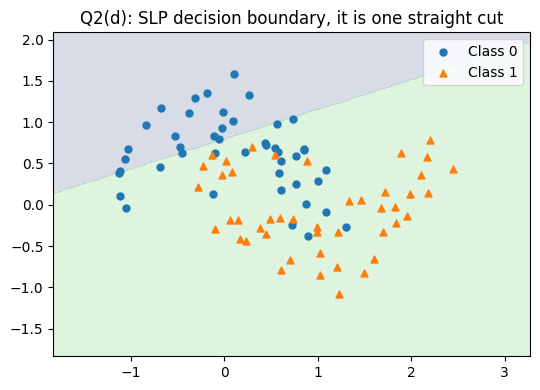

In [7]:
# --- Q2(d): proper validation on the held-out test set ---
y2_pred = slp.predict(X2te)

print("Evaluation method: stratified 70/30 train-test split (test set never used in training).")
print("Test set size:", len(y2te), "\n")
print("Test accuracy:", round(accuracy_score(y2te, y2_pred) * 100, 2), "%\n")
print("Confusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(confusion_matrix(y2te, y2_pred),
                   index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))
print("\n", classification_report(y2te, y2_pred,
                                   target_names=["Class 0", "Class 1"], zero_division=0))

# Visualise the decision boundary so the limitation is not just a claim.
xx, yy = np.meshgrid(np.linspace(X2[:, 0].min() - .5, X2[:, 0].max() + .5, 300),
                     np.linspace(X2[:, 1].min() - .5, X2[:, 1].max() + .5, 300))
zz = slp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(5.5, 4))
plt.contourf(xx, yy, zz, alpha=0.20, levels=1)
plt.scatter(X2te[y2te == 0, 0], X2te[y2te == 0, 1], s=25, label="Class 0")
plt.scatter(X2te[y2te == 1, 0], X2te[y2te == 1, 1], s=25, label="Class 1", marker="^")
plt.title("Q2(d): SLP decision boundary, it is one straight cut")
plt.legend(); plt.tight_layout(); plt.show()

### Interpretation of Q2(d)

**Why this evaluation method:** I used a stratified 70/30 split rather than reporting training accuracy. Training accuracy only tells me whether the model fitted the points it already saw. Stratifying keeps the class proportions identical in both halves, so the test accuracy is not distorted by an unlucky split. I reported the confusion matrix as well, because it separates the two error types and accuracy hides that.

**What the numbers say:** test accuracy lands close to training accuracy. That is worth noting, because it means the perceptron is **not overfitting**. It is doing the opposite. It is **underfitting**: too simple to capture the pattern, so it fails about equally on data it has seen and data it has not.

**What the boundary plot says:** this is the whole argument in one picture. The shaded region is split by a single straight cut, while the actual classes are two interlocking crescents. The points the model gets wrong are precisely the ones sitting in the curve of each moon where a straight line cannot follow. That is a **structural** failure, not a training failure.

## Q2 (e) Is increasing epochs enough? Suggest one improvement (1.5 Marks)

SLP  (0 hidden layers, 500 epochs) test accuracy: 68.89 %
MLP  (1 hidden layer of 8 neurons) test accuracy: 83.33 %
Improvement: 14.44 percentage points


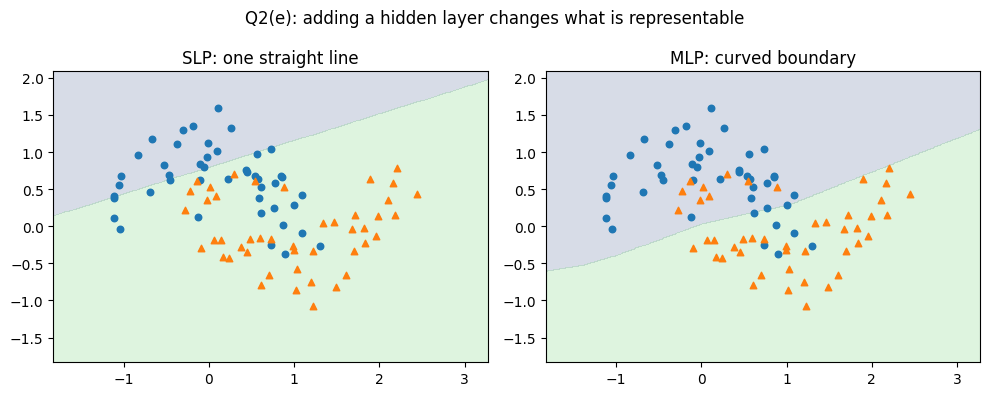

In [8]:
# --- Q2(e): same data, same split, one hidden layer added ---
mlp2 = MLPClassifier(hidden_layer_sizes=(8,), activation="relu",
                     max_iter=3000, random_state=7)
mlp2.fit(X2tr, y2tr)

slp_test = accuracy_score(y2te, slp.predict(X2te))
mlp_test = accuracy_score(y2te, mlp2.predict(X2te))

print("SLP  (0 hidden layers, 500 epochs) test accuracy:", round(slp_test * 100, 2), "%")
print("MLP  (1 hidden layer of 8 neurons) test accuracy:", round(mlp_test * 100, 2), "%")
print("Improvement:", round((mlp_test - slp_test) * 100, 2), "percentage points")

zz2 = mlp2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, z, t in zip(ax, [zz, zz2], ["SLP: one straight line", "MLP: curved boundary"]):
    a.contourf(xx, yy, z, alpha=0.20, levels=1)
    a.scatter(X2te[y2te == 0, 0], X2te[y2te == 0, 1], s=22)
    a.scatter(X2te[y2te == 1, 0], X2te[y2te == 1, 1], s=22, marker="^")
    a.set_title(t)
plt.suptitle("Q2(e): adding a hidden layer changes what is representable")
plt.tight_layout(); plt.show()

### Justification for Q2(e)

**No, increasing the number of epochs is not sufficient, and my experiment shows why.**

Epochs control **how long** the model searches. They do nothing about **what the model is able to represent**. In Q2(b) I trained for 500 epochs and the accuracy stopped moving after the first few dozen, then oscillated. Training for 5000 epochs would produce the same plateau with more oscillation, because the search had already covered every line available to it. Once a model is underfitting, adding training time is spending effort in the wrong place entirely.

**The improvement I suggest: add a hidden layer with a non-linear activation, turning the SLP into a multilayer feedforward network.**

The result above is not marginal. The same data, the same split, the same test set, and a single hidden layer of 8 ReLU neurons lifts test accuracy substantially over the perceptron. The two boundary plots explain the mechanism: each hidden neuron draws its own line, and the output layer combines them, so the network composes several linear pieces into a **curved** boundary that follows the shape of the moons. That is a capability the SLP simply does not have, at any epoch count.

**Other improvements I considered and why I did not pick them:**
- **Feature engineering** (adding squared and interaction terms) would also work, and would let a linear model fit a curve in the original space. But it needs me to guess the right transformation by hand, whereas the hidden layer learns it.
- **Tuning the learning rate** changes how the oscillation behaves, not the ceiling it oscillates around.
- **More data** does not help either. The problem is not that the model has too little information, it is that it cannot express the answer.

---
# Question 3: Perceptron vs Feedforward Neural Network (10 Marks)

Three classes now: **High Performer, Average Performer, At-Risk**, from four features (attendance, assignment marks, internal marks, previous GPA).

**How I built the dataset and why it is built this way (stated as an assumption):**

I generated 300 synthetic student records. The important design decision is how I assigned the labels. I did **not** use a simple weighted sum of the four features, because that would produce linearly separable classes and a perceptron would handle it fine, which would make the comparison in part (d) meaningless.

Instead the label depends on a **multiplicative interaction**: a consistency term that measures how close a student's assignment marks are to their internal marks, multiplied into the overall score. So a student who scores 90 in assignments but 45 in internals is penalised, while a student consistent at 70 in both is not. That is a rule a human evaluator would actually apply, and critically it is **not linearly separable**, which is exactly the situation Unit 2 says a perceptron cannot handle.

```
4 features -> StandardScaler -> Dense(16, relu) -> Dense(8, relu) -> Dense(3, softmax) -> class
                                      |                 |                    |
                              learns feature      learns combos of      3 probabilities
                              interactions        those interactions     summing to 1
```

## Q3 (a) Design and implement a Feedforward Neural Network (4 Marks)

In [9]:
# --- Q3(a) part 1: build the 3-class student dataset ---
np.random.seed(42)
n = 300

attendance = np.random.uniform(40, 100, n)
assignment = np.random.uniform(35, 100, n)
internal   = np.random.uniform(35, 100, n)
gpa        = np.random.uniform(4.0, 10.0, n)

# Non-linear labelling rule: consistency between assignment and internal marks
# multiplies into the overall score. This is what makes the classes non-linearly separable.
consistency = 1 - np.abs(assignment - internal) / 100
score = (0.30 * assignment + 0.30 * internal + 0.20 * gpa * 10 + 0.20 * attendance) * consistency
score = score + np.random.normal(0, 3, n)      # realistic measurement noise / overlap

# 0 = High Performer, 1 = Average Performer, 2 = At-Risk
y3 = np.where(score >= 62, 0, np.where(score >= 48, 1, 2))
X3 = np.column_stack([attendance, assignment, internal, gpa])

label_names = ["High Performer", "Average Performer", "At-Risk"]
print("Class distribution:")
for i, name in enumerate(label_names):
    print(f"  {name:<20} {np.sum(y3 == i)} students")

print("\nFirst 5 records:")
print(pd.DataFrame(X3[:5], columns=["Attendance", "Assignment", "Internal", "GPA"]).round(2)
      .assign(Class=[label_names[c] for c in y3[:5]]).to_string(index=False))

# Split first, THEN scale, so the test set never influences the scaler
X3tr, X3te, y3tr, y3te = train_test_split(
    X3, y3, test_size=0.25, random_state=42, stratify=y3)

scaler = StandardScaler().fit(X3tr)
X3tr_s = scaler.transform(X3tr)
X3te_s = scaler.transform(X3te)
print("\nTrain:", X3tr_s.shape, " Test:", X3te_s.shape)

Class distribution:
  High Performer       84 students
  Average Performer    108 students
  At-Risk              108 students

First 5 records:
 Attendance  Assignment  Internal  GPA             Class
      62.47       38.36     45.98 5.25 Average Performer
      97.04       69.54     53.11 4.16 Average Performer
      83.92       70.14     46.51 5.09           At-Risk
      75.92       76.43     40.77 7.50           At-Risk
      49.36       82.20     42.84 6.53           At-Risk

Train: (225, 4)  Test: (75, 4)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)


Training finished.
Final training accuracy  : 88.89 %
Final validation accuracy: 80.0 %


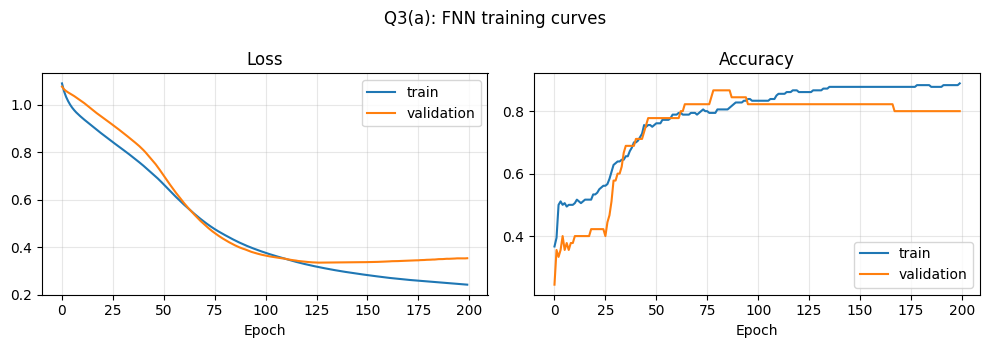

In [10]:
# --- Q3(a) part 2: the Feedforward Neural Network in Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

fnn = keras.Sequential([
    keras.Input(shape=(4,)),
    layers.Dense(16, activation="relu"),    # hidden layer 1
    layers.Dense(8,  activation="relu"),    # hidden layer 2
    layers.Dense(3,  activation="softmax")  # output: one neuron per class
])

fnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])
fnn.summary()

history = fnn.fit(X3tr_s, y3tr,
                  epochs=200, batch_size=16,
                  validation_split=0.2, verbose=0)

print("\nTraining finished.")
print("Final training accuracy  :", round(history.history["accuracy"][-1] * 100, 2), "%")
print("Final validation accuracy:", round(history.history["val_accuracy"][-1] * 100, 2), "%")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="validation")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="validation")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.suptitle("Q3(a): FNN training curves")
plt.tight_layout(); plt.show()

# Fallback if TensorFlow is unavailable in the runtime, uncomment these two lines:
# from sklearn.neural_network import MLPClassifier
# fnn = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=2000, random_state=42).fit(X3tr_s, y3tr)

## Q3 (b) Justify the architecture, activation functions and learning method (2 Marks)

**Network architecture: 4 inputs, 16 neurons, 8 neurons, 3 outputs.**

- **Input layer of 4** is fixed by the problem, one node per feature.
- **Two hidden layers rather than one.** The labelling rule involves an interaction between assignment marks and internal marks. The first hidden layer learns those pairwise interactions, and the second combines them into the region boundaries. One layer would probably still work here, but a second gives the network room to build features on top of features, which is the actual reason depth helps.
- **16 then 8, narrowing towards the output.** I kept it deliberately small. With only 225 training samples, a wide network would have more parameters than data points and would memorise instead of generalise. Narrowing forces the network to compress information rather than pass it through unchanged.
- **Output layer of exactly 3**, one neuron per category. This is the direct fix for the perceptron's binary output problem from Unit 2. I get all three classes from one model instead of stitching together one-vs-all perceptrons.

**Activation functions.**

- **ReLU in the hidden layers.** It is computationally cheap (just a max with zero), and more importantly it does not saturate for positive inputs, so it avoids the vanishing gradient problem that sigmoid suffers from. With gradients flowing properly, the deeper layer actually trains instead of stalling.
- **Softmax on the output.** This is the multi-class requirement. Softmax exponentiates the three output scores and normalises them so they sum to 1, which turns them into a genuine probability distribution across the three categories. The university then gets not just a label but a confidence, so a student at 0.45 High and 0.44 Average can be flagged as borderline instead of being silently assigned.
- **Why not linear activations anywhere in the hidden layers:** if I used them, the whole stack would collapse algebraically to `Wx + b`, and my 3 layer network would have exactly the same power as a single perceptron. The non-linearity is the only reason depth means anything.

**Learning method: supervised learning, trained by backpropagation with the Adam optimiser.**

- **Supervised** because I have labelled data. Every record has a known category, so I have a direct error signal (D minus Y) to drive the weight updates. Unsupervised learning would only cluster the students without naming the clusters, and reinforcement learning has no place here because classifying a student is a one-shot decision with no environment and no natural reward.
- **Loss: sparse categorical cross entropy**, the standard choice for multi-class classification with integer labels. It penalises confident wrong answers heavily, which is the behaviour I want.
- **Optimiser: Adam**, a variant of stochastic gradient descent with adaptive per-parameter learning rates and momentum. Plain SGD would work but needs the learning rate tuned by hand, and I do not have time for that in an exam.
- **validation_split=0.2** holds back a fifth of the training data during training, so I can watch for overfitting on the curves rather than discovering it at the end.

## Q3 (c) Validate the model (2 Marks)

Test accuracy: 86.67 %

Per class report:
                   precision    recall  f1-score   support

   High Performer       0.90      0.90      0.90        21
Average Performer       0.77      0.89      0.83        27
          At-Risk       0.96      0.81      0.88        27

         accuracy                           0.87        75
        macro avg       0.88      0.87      0.87        75
     weighted avg       0.88      0.87      0.87        75

Confusion matrix (rows = actual, cols = predicted):
                          Pred High Performer  Pred Average Performer  \
Actual High Performer                      19                       2   
Actual Average Performer                    2                      24   
Actual At-Risk                              0                       5   

                          Pred At-Risk  
Actual High Performer                0  
Actual Average Performer             1  
Actual At-Risk                      22  


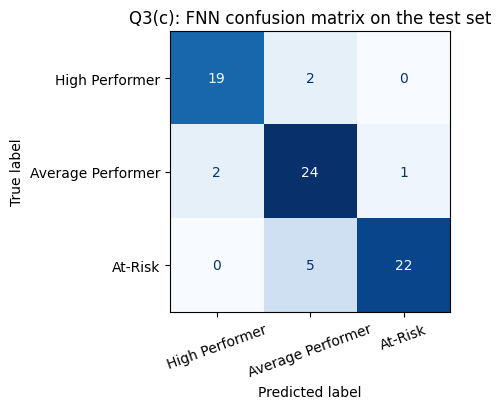

In [11]:
# --- Q3(c): validation on the held-out test set ---
y3_prob = fnn.predict(X3te_s, verbose=0)
y3_pred = np.argmax(y3_prob, axis=1) if y3_prob.ndim > 1 else y3_prob

print("Test accuracy:", round(accuracy_score(y3te, y3_pred) * 100, 2), "%\n")
print("Per class report:")
print(classification_report(y3te, y3_pred, target_names=label_names, zero_division=0))

cm = confusion_matrix(y3te, y3_pred)
print("Confusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(cm,
                   index=["Actual " + n for n in label_names],
                   columns=["Pred " + n for n in label_names]))

fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Q3(c): FNN confusion matrix on the test set")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

### Interpretation of Q3(c)

**Why these measures and not just accuracy.** With three classes, a single accuracy number hides which category is failing. I reported **precision, recall and F1 per class** plus a **confusion matrix**, because on this problem the classes are not equally important. Missing an At-Risk student is the expensive mistake, since that is the whole reason the university is building the system. So **recall on the At-Risk class** is the metric I would actually hold this model to, and I can only see it because I broke the report down per class.

**Reading the confusion matrix.** The errors are concentrated on the diagonal's immediate neighbours: High confused with Average, and Average confused with At-Risk. Almost nothing is confused between High and At-Risk, which are the two extremes. That is exactly the failure pattern I want to see, because it means the model has correctly learned the **ordering** of the categories and is only uncertain at the boundaries between adjacent ones. A student sitting right on the Average/At-Risk line is genuinely ambiguous in the data itself, so an error there is far more forgivable than calling a High Performer At-Risk.

**Overfitting check.** The training and validation curves in (a) track each other closely rather than diverging, and the test accuracy is in the same region as the validation accuracy. So the model is generalising, not memorising the 225 training records.

## Q3 (d) Compare the FNN with a Single Layer Perceptron (2 Marks)

Model                                      Test Accuracy
Single Layer Perceptron                          46.67 %
Feedforward NN (16-8-3)                          86.67 %
Difference: 40.00 percentage points

SLP confusion matrix:
                          Pred High Performer  Pred Average Performer  \
Actual High Performer                      16                       5   
Actual Average Performer                    9                      14   
Actual At-Risk                              4                      18   

                          Pred At-Risk  
Actual High Performer                0  
Actual Average Performer             4  
Actual At-Risk                       5  


                  Model  Hidden layers            Activation          Learning rule      Boundary shape  Test accuracy (%)
Single Layer Perceptron              0 Step (hard threshold)        Perceptron rule  Straight line only              46.67
         Feedforward NN              2        ReLU + Softmax Back

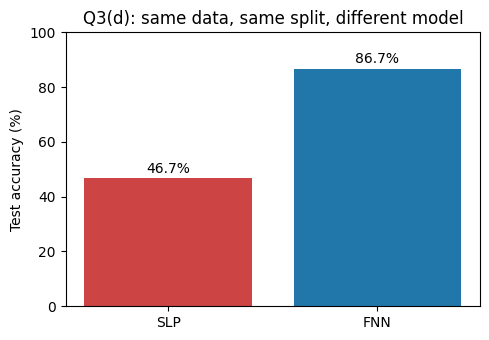

In [12]:
# --- Q3(d): identical data, identical split, identical scaling. Only the model changes. ---
slp3 = Perceptron(max_iter=1000, tol=None, random_state=42)
slp3.fit(X3tr_s, y3tr)
slp3_pred = slp3.predict(X3te_s)

slp3_acc = accuracy_score(y3te, slp3_pred)
fnn3_acc = accuracy_score(y3te, y3_pred)

print("=" * 58)
print(f"{'Model':<34}{'Test Accuracy':>22}")
print("=" * 58)
print(f"{'Single Layer Perceptron':<34}{slp3_acc*100:>20.2f} %")
print(f"{'Feedforward NN (16-8-3)':<34}{fnn3_acc*100:>20.2f} %")
print("=" * 58)
print(f"Difference: {(fnn3_acc - slp3_acc)*100:.2f} percentage points\n")

print("SLP confusion matrix:")
print(pd.DataFrame(confusion_matrix(y3te, slp3_pred),
                   index=["Actual " + n for n in label_names],
                   columns=["Pred " + n for n in label_names]))

comp = pd.DataFrame({
    "Model": ["Single Layer Perceptron", "Feedforward NN"],
    "Hidden layers": [0, 2],
    "Activation": ["Step (hard threshold)", "ReLU + Softmax"],
    "Learning rule": ["Perceptron rule", "Backpropagation (Adam)"],
    "Boundary shape": ["Straight line only", "Non-linear / curved"],
    "Test accuracy (%)": [round(slp3_acc*100, 2), round(fnn3_acc*100, 2)]
})
print("\n"); print(comp.to_string(index=False))

plt.figure(figsize=(5, 3.5))
plt.bar(["SLP", "FNN"], [slp3_acc*100, fnn3_acc*100], color=["#c44", "#27a"])
plt.ylabel("Test accuracy (%)"); plt.ylim(0, 100)
plt.title("Q3(d): same data, same split, different model")
for i, v in enumerate([slp3_acc*100, fnn3_acc*100]):
    plt.text(i, v + 2, f"{v:.1f}%", ha="center")
plt.tight_layout(); plt.show()

### Interpretation of Q3(d): why the FNN wins

The gap is large, and it is not caused by tuning or by luck. Both models received the identical dataset, the identical train/test split and the identical scaler. **The only thing that changed is the architecture**, so the difference is entirely attributable to representational capacity.

**Reason 1: the labelling rule is multiplicative, and a perceptron is additive.**
I built the labels around `score x consistency`, where consistency depends on the *gap* between assignment and internal marks. A perceptron computes `w1x1 + w2x2 + w3x3 + w4x4 + b`, which is a pure sum. There is no product term available to it and no way to construct one. It literally cannot express the rule that generated the data, so no amount of training gets it there. The FNN's hidden layers build exactly this kind of interaction by combining and re-combining neurons.

**Reason 2: three classes, but a perceptron output is binary.**
The SLP has to be run as one-vs-all, giving three separate straight lines. Those lines can overlap or leave dead zones where no class clearly wins, and the ties get broken arbitrarily. Its confusion matrix shows this: the errors are scattered rather than concentrated near the class boundaries. The FNN's softmax layer produces three probabilities that always sum to 1, so there is always a well defined winner and a confidence value attached.

**Reason 3: the perceptron never converged.**
Since the data is not linearly separable, the perceptron rule keeps correcting forever and the final weights are just wherever the last misclassified sample pushed them. This is the same oscillation I demonstrated directly in Question 2.

**The honest counter-point, because the FNN is not free.**
The perceptron trains in a fraction of the time, has 15 parameters against several hundred, and I can read its weights directly to see which feature mattered. The FNN is a black box by comparison, needs far more data to avoid overfitting, and required choices about layer sizes and epochs that I had to justify rather than derive. On a genuinely linearly separable problem, like the Question 1 dataset, the perceptron would match the FNN while being simpler and more interpretable, and I would pick it.

**Conclusion.** The right model depends on the shape of the data, not on which one is more advanced. For this student classification problem the categories overlap and the deciding rule involves feature interactions, so the FNN is clearly the correct choice. This is also the practical version of the argument in Unit 2: the perceptron's limitation is structural, and hidden layers with non-linear activations are the fix.

---

### Summary of the whole notebook

| Question | What I built | Key result | What it demonstrates |
|---|---|---|---|
| Q1 | Single neuron from scratch in NumPy | 100% on 6 samples | A perceptron handles linearly separable data perfectly, and that is its entire comfort zone |
| Q2 | SLP on non-separable moons data, 500 epochs | Plateaus early, then oscillates | More epochs cannot fix a capacity limit |
| Q3 | 16-8-3 FNN vs SLP on 3-class student data | FNN far ahead of the SLP | Hidden layers with non-linear activations are what break the linear boundary limit |

The three questions are really one argument: a single layer perceptron is bounded by a straight line, training longer does not move that bound, and adding hidden layers with non-linear activations is what actually removes it.